# Mapping Service Delivery Needs in Gauteng

Welcome to this starter notebook for the **Mapping Service Delivery Needs in Gauteng** challenge.

Across Gauteng, many households still lack reliable access to essential services — piped water, formal sanitation, refuse collection, electricity, and quality education. These service gaps rarely occur in isolation: a household without piped water is also more likely to lack formal sanitation and refuse collection. This challenge asks you to predict, simultaneously, whether each of five services is accessible to a given household — making it a **multi-label classification** problem, not five separate tasks.

Because these service gaps tend to co-occur, the best solutions will look beyond each label in isolation and capture the broader patterns of unmet need. The insights from this challenge could help shape smarter, fairer decisions about where and how to invest in service delivery across Gauteng.

This notebook gives you a fully working baseline — from loading the data to generating your first submission file.

## Domain context

The data is derived from the **GCRO Quality of Life Survey**, a large-scale household survey conducted across Gauteng Province, South Africa. The survey covers housing, household composition, income, employment, health, and access to public services.

**The five service-gap labels** are the prediction targets. Each label equals **1 if the household faces a service gap** and **0 if it has access**:

| Label | Service gap (= 1) means … |
|---|---|
| `no_water_access` | No piped water on-site |
| `no_sanitation_access` | No flush / chemical toilet |
| `no_refuse_access` | No formal weekly refuse removal |
| `no_energy_access` | No electricity in the dwelling |
| `no_education_access` | Highest education is primary school or below |

These gaps **co-occur** — a household without piped water is more likely to also lack sanitation and refuse collection — which is exactly why this is framed as a single **multi-label** problem rather than five independent ones.

**The feature set (25 features)** captures socio-economic, demographic, and geographic characteristics of each household. Every feature is **categorical** (stored as text), and falls into one of three kinds — *binary* (Yes/No or 0/1), *ordinal bands* (ordered ranges such as `3-4`, `5-6`), and *nominal* categories (unordered, e.g. `transport_mode`). The values below are taken from `data_dictionary.csv`:

| Feature | Kind | Values | What it captures |
|---|---|---|---|
| `age_band` | ordinal | `<25` … `65+`, `__SUPPRESSED__` | Respondent age band (`__SUPPRESSED__` = withheld for privacy) |
| `sex` | nominal | Female; Male | Respondent sex |
| `pop_group` | nominal | Black African; Coloured; Indian/Asian; White | Population group |
| `marital` | nominal | Single; Married/common law; In a relationship; Divorced; Widowed | Marital status |
| `hh_size_band` | ordinal | 1; 2; 3-4; 5-6; 7+ | Household size |
| `children_band` | ordinal | 0; 1; 2; 3+ | Number of children |
| `elderly_band` | binary | 0; 1 | Any elderly member in household |
| `rooms_band` | ordinal | 1-2; 3-4; 5+ | Number of rooms in dwelling |
| `head_household` | nominal | Respondent; Spouse; Mother; Father; Grandmother (of respondent) | Relationship of respondent to household head |
| `dwelling_type` | nominal | Formal; Informal | Type of dwelling |
| `tenure` | nominal | Owned; Renting; Rent-free by owner; Squatting / informal | Tenure status |
| `asset_index` | ordinal | 0-2; 3-4; 5-6; 7-8; 9+ | Count of household assets owned |
| `debt_count` | ordinal | 0; 1; 2; 3+ | Number of debts |
| `internet` | binary | No; Yes | Has internet access |
| `food_insecurity` | nominal | secure; insecure | Food-security status |
| `employed` | binary | No; Yes | Currently employed |
| `income_src_count` | ordinal | 0; 1; 2+ | Number of income sources |
| `social_grant` | binary | No; Yes | Receives a government social grant |
| `hazard_count` | ordinal | 0; 1; 2; 3+ | Number of environmental hazards faced |
| `amenity_access` | ordinal | 0-2; 3-4; 5-6; 7+ | Number of nearby amenities accessible |
| `transport_mode` | nominal | Walk; Minibus Taxi; Car as passenger; Car as driver | Main transport mode |
| `chronic_count` | ordinal | 0; 1; 2+ | Number of chronic health conditions |
| `medical_aid` | binary | No; Yes | Has medical aid / health insurance |
| `health_status` | ordinal | Poor; Good; Excellent | Self-rated health |
| `crime_victim` | binary | No; Yes | Was a victim of crime |

> Not every category necessarily appears in the training sample (for example `pop_group = Coloured` is rare); the one-hot encoder is configured with `handle_unknown='ignore'` so any category seen only at prediction time is handled gracefully.
</cell id="8498ef83" >

## Setup

Install any packages not already available in your environment.

In [1]:
# Uncomment and run if packages are missing
!pip install scikit-learn pandas numpy matplotlib scipy -q


In [2]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, hamming_loss
from scipy.stats import chi2_contingency

print('All imports successful')


All imports successful


## Configuration

All file paths and key settings are defined here. Adjust `BASE_DIR` if you have stored the data files in a different location.

In [3]:
from pathlib import Path

BASE = Path('.')

BASE_DIR        = str(BASE)
SUBMISSION_FILE = str(BASE / 'submission.csv')

TRAIN_FILE      = f'{BASE_DIR}/train.csv'
VAL_FILE        = f'{BASE_DIR}/val.csv'
TEST_FILE       = f'{BASE_DIR}/test.csv'
SAMPLE_SUB_FILE = f'{BASE_DIR}/SampleSubmission.csv'

ID_COL      = 'ID'
TARGET_COLS = [
    'no_water_access', 'no_sanitation_access', 'no_refuse_access',
    'no_energy_access', 'no_education_access',
]

# All 25 features are categorical (text). The baseline one-hot encodes them,
# so no manual numeric encoding is required here.
FEATURE_COLS = [
    # demographics
    'age_band', 'sex', 'pop_group', 'marital',
    # household composition
    'hh_size_band', 'children_band', 'elderly_band', 'rooms_band', 'head_household',
    # housing & tenure
    'dwelling_type', 'tenure',
    # economic
    'asset_index', 'debt_count', 'internet', 'food_insecurity',
    'employed', 'income_src_count', 'social_grant',
    # environment & services
    'hazard_count', 'amenity_access', 'transport_mode',
    # health
    'chronic_count', 'medical_aid', 'health_status', 'crime_victim',
]

RANDOM_STATE = 42
print('Configuration loaded')
print(f'Features : {len(FEATURE_COLS)}')
print(f'Targets  : {len(TARGET_COLS)}')


Configuration loaded
Features : 25
Targets  : 5


## Load data

Load the training set (features + labels), validation set, test set (no labels), and the sample submission template.

In [4]:
train = pd.read_csv(TRAIN_FILE)
print(f'Train : {train.shape[0]:,} rows × {train.shape[1]} columns')


Train : 8,353 rows × 31 columns


In [5]:
val = pd.read_csv(VAL_FILE)
print(f'Val   : {val.shape[0]:,} rows × {val.shape[1]} columns')


Val   : 1,080 rows × 31 columns


In [6]:
test = pd.read_csv(TEST_FILE)
print(f'Test  : {test.shape[0]:,} rows × {test.shape[1]} columns')


Test  : 4,060 rows × 26 columns


In [7]:
sample_sub = pd.read_csv(SAMPLE_SUB_FILE)
print(f'Sample submission: {sample_sub.shape[0]:,} rows × {sample_sub.shape[1]} columns')
print('Columns:', list(sample_sub.columns))


Sample submission: 4,060 rows × 6 columns
Columns: ['ID', 'no_water_access', 'no_sanitation_access', 'no_refuse_access', 'no_energy_access', 'no_education_access']


## Exploratory data analysis

A quick look at the training data before modelling.

In [9]:
# Verify all expected feature columns are present, and show their type / cardinality
missing_cols = [f for f in FEATURE_COLS if f not in train.columns]
print(f'Missing feature columns: {missing_cols if missing_cols else "None — all 25 present"}')
print()
print(f'{"feature":<18}{"dtype":<10}{"n_unique":>9}   sample values')
for col in FEATURE_COLS:
    uniq = sorted(train[col].dropna().unique().tolist(), key=str)
    preview = ', '.join(map(str, uniq[:4])) + (' …' if len(uniq) > 4 else '')
    print(f'{col:<18}{str(train[col].dtype):<10}{train[col].nunique():>9}   {preview}')


Missing feature columns: None — all 25 present

feature           dtype      n_unique   sample values
age_band          object            7   25-34, 35-44, 45-54, 55-64 …
sex               object            2   Female, Male


pop_group         object            3   Black African, Indian/Asian, White
marital           object            5   Divorced, In a relationship but not married, Married/common law marriage, Single …
hh_size_band      object            5   1, 2, 3-4, 5-6 …
children_band     object            4   0, 1, 2, 3+
elderly_band      int64             2   0, 1
rooms_band        object            3   1-2, 3-4, 5+
head_household    object            5   Father of respondent, Grandmother of respondent, Mother of respondent, Respondent …
dwelling_type     object            2   Formal, Informal
tenure            object            4   Allowed to stay rent free by owner, Owned, Renting, Squatting or living rent-free in an informal dwelling youve built, or in a vacant building or on vacant land
asset_index       object            5   0-2, 3-4, 5-6, 7-8 …
debt_count        object            4   0, 1, 2, 3+
internet          object            2   No, Yes


food_insecurity   object            2   insecure, secure
employed          object            2   No, Yes
income_src_count  object            3   0, 1, 2+
social_grant      object            2   No, Yes
hazard_count      object            4   0, 1, 2, 3+
amenity_access    object            4   0-2, 3-4, 5-6, 7+
transport_mode    object            4   Car as driver, Car as passenger, Minibus Taxi, Walk
chronic_count     object            3   0, 1, 2+
medical_aid       object            2   No, Yes
health_status     object            3   Excellent, Good, Poor
crime_victim      object            2   No, Yes


In [10]:
# Missing values per feature
missing = train[FEATURE_COLS].isna().mean().sort_values(ascending=False)
print('Missing value rate per feature:')
for col, rate in missing.items():
    print(f'  {col:<20}  {rate:.1%}')


Missing value rate per feature:
  age_band              0.0%
  internet              0.0%
  health_status         0.0%
  medical_aid           0.0%
  chronic_count         0.0%
  transport_mode        0.0%
  amenity_access        0.0%
  hazard_count          0.0%
  social_grant          0.0%
  income_src_count      0.0%
  employed              0.0%
  food_insecurity       0.0%
  debt_count            0.0%
  sex                   0.0%
  asset_index           0.0%
  tenure                0.0%
  dwelling_type         0.0%
  head_household        0.0%
  rooms_band            0.0%
  elderly_band          0.0%
  children_band         0.0%
  hh_size_band          0.0%
  marital               0.0%
  pop_group             0.0%
  crime_victim          0.0%


In [11]:
# Service gap rates in the training set (% of households facing each gap)
rates = train[TARGET_COLS].mean() * 100
print('Service gap rate per label (training set, 1 = service gap):')
for col, rate in rates.items():
    bar = '█' * int(rate / 2)
    print(f'  {col:<25} {rate:5.1f}%  {bar}')


Service gap rate per label (training set, 1 = service gap):
  no_water_access            27.5%  █████████████
  no_sanitation_access        9.2%  ████
  no_refuse_access           22.9%  ███████████
  no_energy_access            4.0%  ██
  no_education_access         9.6%  ████


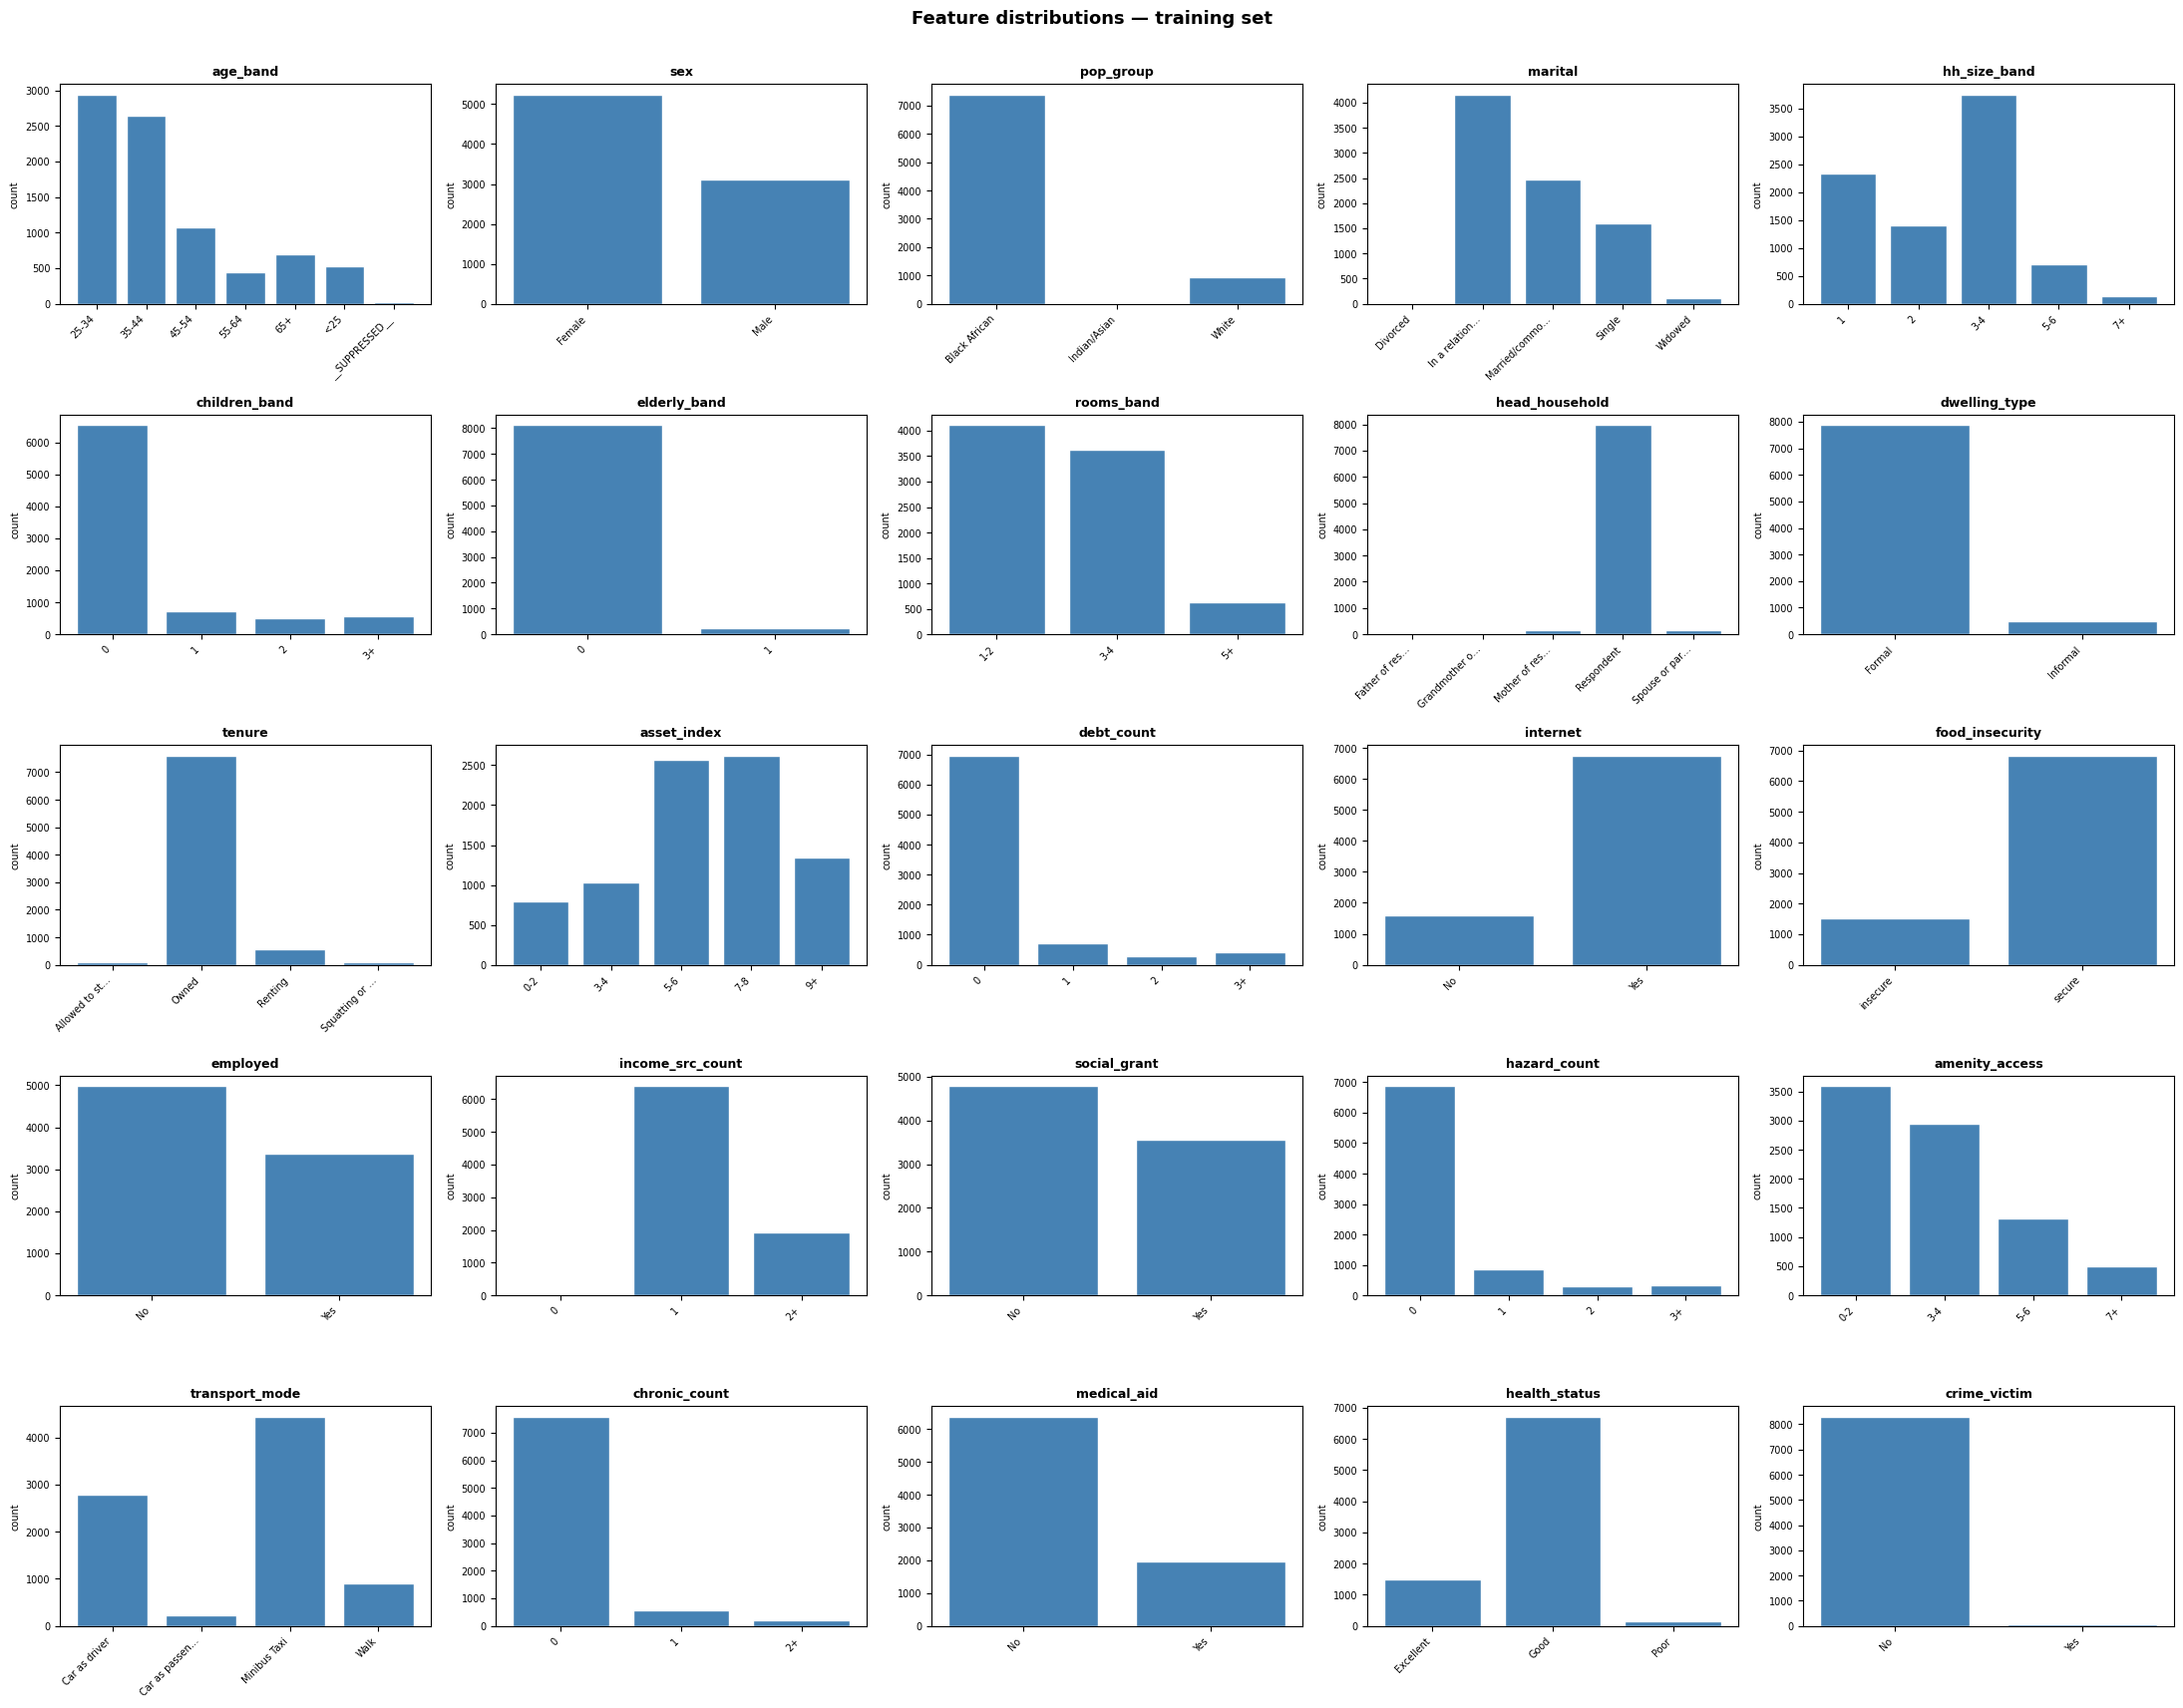

Chart saved.


In [12]:
# Feature value distributions — one bar chart per categorical feature
n = len(FEATURE_COLS)
ncols = 5
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 3.4 * nrows))
axes = axes.flat

def short(s, k=14):
    s = str(s)
    return s if len(s) <= k else s[:k - 1] + '…'

for ax, feat in zip(axes, FEATURE_COLS):
    vc = train[feat].value_counts(dropna=False).sort_index()
    ax.bar(range(len(vc)), vc.values, color='steelblue', edgecolor='white')
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels([short(x) for x in vc.index], rotation=45, ha='right', fontsize=7)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_ylabel('count', fontsize=7)
    ax.tick_params(axis='y', labelsize=7)
# hide spare axes
for ax in list(axes)[n:]:
    ax.set_visible(False)
plt.suptitle('Feature distributions — training set', fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(str(BASE / 'feature_distributions.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved.')


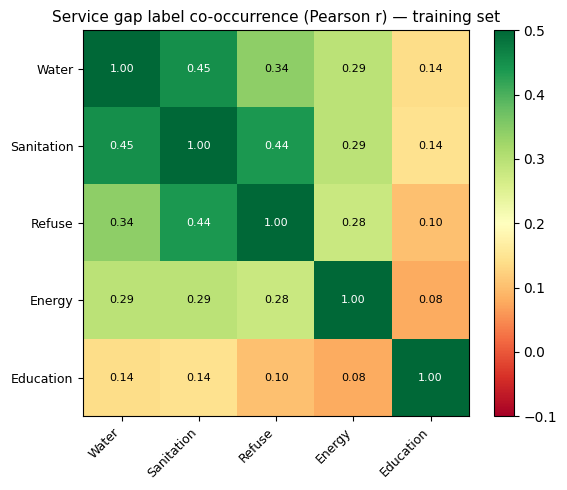

Chart saved to label_cooccurrence.png


In [13]:
# Label co-occurrence heat-map
fig, ax = plt.subplots(figsize=(7, 5))
corr = train[TARGET_COLS].corr()
labels_short = ['Water', 'Sanitation', 'Refuse', 'Energy', 'Education']
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-0.1, vmax=0.5)
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels(labels_short, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels_short, fontsize=9)
ax.set_title('Service gap label co-occurrence (Pearson r) — training set', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='black' if abs(corr.values[i,j]) < 0.35 else 'white')
plt.tight_layout()
plt.savefig(str(BASE / 'label_cooccurrence.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved to label_cooccurrence.png')

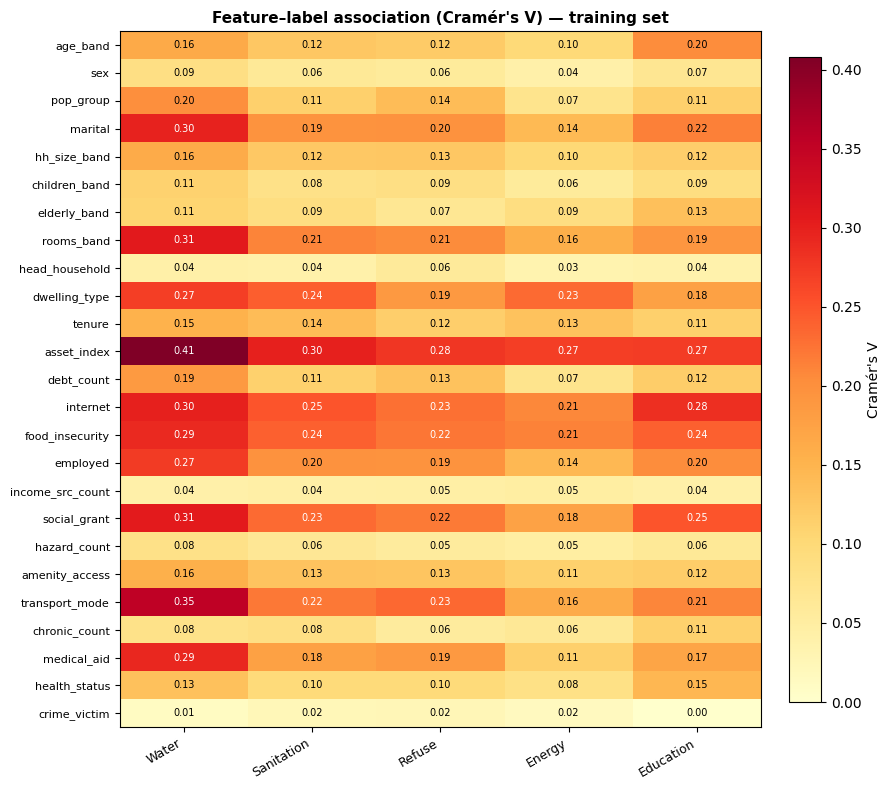

Chart saved.


In [14]:
# Feature–label association overview (Cramér's V)
# The features are categorical, so Pearson correlation does not apply. Cramér's V
# measures the association between two categorical variables on a 0–1 scale
# (0 = none, 1 = perfect) and works for any number of categories.
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / min(r - 1, k - 1))

assoc = pd.DataFrame(index=FEATURE_COLS, columns=TARGET_COLS, dtype=float)
for feat in FEATURE_COLS:
    for tgt in TARGET_COLS:
        assoc.loc[feat, tgt] = cramers_v(train[feat], train[tgt])

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(assoc.values, cmap='YlOrRd', vmin=0,
               vmax=float(np.nanmax(assoc.values)), aspect='auto')
ax.set_xticks(range(len(TARGET_COLS)))
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_xticklabels(['Water', 'Sanitation', 'Refuse', 'Energy', 'Education'],
                   rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(FEATURE_COLS, fontsize=8)
ax.set_title("Feature–label association (Cramér's V) — training set",
             fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Cramér's V")
for i in range(len(FEATURE_COLS)):
    for j in range(len(TARGET_COLS)):
        v = assoc.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if v > 0.22 else 'black')
plt.tight_layout()
plt.savefig(str(BASE / 'feature_label_association.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved.')

## Baseline model

The baseline is a `Pipeline` of two steps:

1. **`OneHotEncoder`** (inside a `ColumnTransformer`) turns the 25 categorical features into binary indicator columns. `handle_unknown='ignore'` means any category that appears only in the validation or test set — and not in training — is encoded as all-zeros rather than raising an error.
2. **`MultiOutputClassifier`** wrapping a **`RandomForestClassifier`** fits one random forest per label, which is a simple and effective way to handle the multi-label structure.

`class_weight='balanced'` re-weights each forest to counter the strong class imbalance — several labels (e.g. `no_energy_access` at ~4%) are rare, and without re-weighting the model would simply predict "no gap" everywhere and score 0 F1 on those labels.

In [15]:
# Prepare feature frames and label arrays.
# Keep X as DataFrames (not .values) so the ColumnTransformer can select columns by name.
X_train = train[FEATURE_COLS]
y_train = train[TARGET_COLS].values.astype(int)

X_val   = val[FEATURE_COLS]
y_val   = val[TARGET_COLS].values.astype(int)

X_test  = test[FEATURE_COLS]

print(f'X_train : {X_train.shape}   y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}   y_val   : {y_val.shape}')
print(f'X_test  : {X_test.shape}')


X_train : (8353, 25)   y_train : (8353, 5)
X_val   : (1080, 25)   y_val   : (1080, 5)
X_test  : (4060, 25)


In [16]:
# One-hot encode the categorical features, then fit one random forest per label
preprocess = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore'), FEATURE_COLS)],
    remainder='drop',
)
base_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',   # compensates for class imbalance on minority labels
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model = Pipeline([
    ('pre', preprocess),
    ('clf', MultiOutputClassifier(base_rf)),
])
model.fit(X_train, y_train)
print('Model trained.')
print('One-hot encoded feature width:',
      len(model.named_steps['pre'].get_feature_names_out()))


Model trained.
One-hot encoded feature width: 84


In [17]:
# Evaluate on validation set
y_val_pred   = model.predict(X_val)
macro_f1     = f1_score(y_val, y_val_pred, average='macro', zero_division=0)
per_label_f1 = f1_score(y_val, y_val_pred, average=None,    zero_division=0)
h_loss       = hamming_loss(y_val, y_val_pred)

print(f'Validation macro-averaged F1 : {macro_f1:.4f}')
print(f'Validation Hamming loss       : {h_loss:.4f}')
print()
print('Per-label F1 (1 = service gap):')
for col, score in zip(TARGET_COLS, per_label_f1):
    bar = '█' * int(score * 20)
    print(f'  {col:<25}  {score:.4f}  {bar}')


Validation macro-averaged F1 : 0.3935
Validation Hamming loss       : 0.1967

Per-label F1 (1 = service gap):
  no_water_access            0.5198  ██████████
  no_sanitation_access       0.3802  ███████
  no_refuse_access           0.4171  ████████
  no_energy_access           0.3036  ██████
  no_education_access        0.3466  ██████


### Tuning the decision threshold (a first improvement)

By default the classifier flags a service gap when its predicted probability passes **0.5**. For imbalanced labels that cutoff is rarely the one that maximises **F1** — moving it trades precision against recall. Below we read probabilities with `predict_proba` and pick the F1-optimal threshold **per label** on the validation set. The raw 0.5-cutoff scores above are left unchanged for comparison.

> ⚠️ **An honest caveat.** Here we both *choose* and *report* the thresholds on the same validation set, so the tuned score is an **optimistic** estimate of true performance — the unbiased check is the competition leaderboard. To turn this into a real submission, apply `best_thresholds` to the **test** probabilities (`model.predict_proba(X_test)`) instead of calling `model.predict` in the prediction step below.

In [18]:
# Threshold tuning — 0.5 is rarely the F1-optimal cutoff, especially for rare labels.
# Read class probabilities with predict_proba, then pick, per label, the threshold
# that maximises F1 on the validation set. (The raw 0.5 scores above are kept as-is.)
val_proba = np.column_stack([p[:, 1] for p in model.predict_proba(X_val)])

grid = np.linspace(0.05, 0.95, 91)
best_thresholds = []
for j in range(len(TARGET_COLS)):
    f1_by_t = [f1_score(y_val[:, j], (val_proba[:, j] >= t).astype(int), zero_division=0)
               for t in grid]
    best_thresholds.append(round(float(grid[int(np.argmax(f1_by_t))]), 2))

y_val_tuned    = (val_proba >= np.array(best_thresholds)).astype(int)
tuned_macro_f1 = f1_score(y_val, y_val_tuned, average='macro', zero_division=0)
tuned_per_lbl  = f1_score(y_val, y_val_tuned, average=None,    zero_division=0)

print('Per-label F1:  default 0.5 cutoff  vs  tuned threshold')
print(f'  {"label":<22}{"thr":>6}{"F1@0.5":>9}{"F1@thr":>9}{"delta":>9}')
for col, thr, base, tuned in zip(TARGET_COLS, best_thresholds, per_label_f1, tuned_per_lbl):
    print(f'  {col:<22}{thr:>6}{base:>9.4f}{tuned:>9.4f}{tuned - base:>+9.4f}')
print()
print(f'Macro-F1:  default 0.5 = {macro_f1:.4f}   ->   tuned = {tuned_macro_f1:.4f}'
      f'   (+{tuned_macro_f1 - macro_f1:.4f})')
print(f'Tuned thresholds: {dict(zip(TARGET_COLS, best_thresholds))}')


Per-label F1:  default 0.5 cutoff  vs  tuned threshold
  label                    thr   F1@0.5   F1@thr    delta
  no_water_access         0.52   0.5198   0.5230  +0.0032
  no_sanitation_access    0.52   0.3802   0.3948  +0.0146
  no_refuse_access         0.4   0.4171   0.4457  +0.0285
  no_energy_access        0.53   0.3036   0.3333  +0.0298
  no_education_access     0.56   0.3466   0.3877  +0.0411

Macro-F1:  default 0.5 = 0.3935   ->   tuned = 0.4169   (+0.0234)
Tuned thresholds: {'no_water_access': 0.52, 'no_sanitation_access': 0.52, 'no_refuse_access': 0.4, 'no_energy_access': 0.53, 'no_education_access': 0.56}


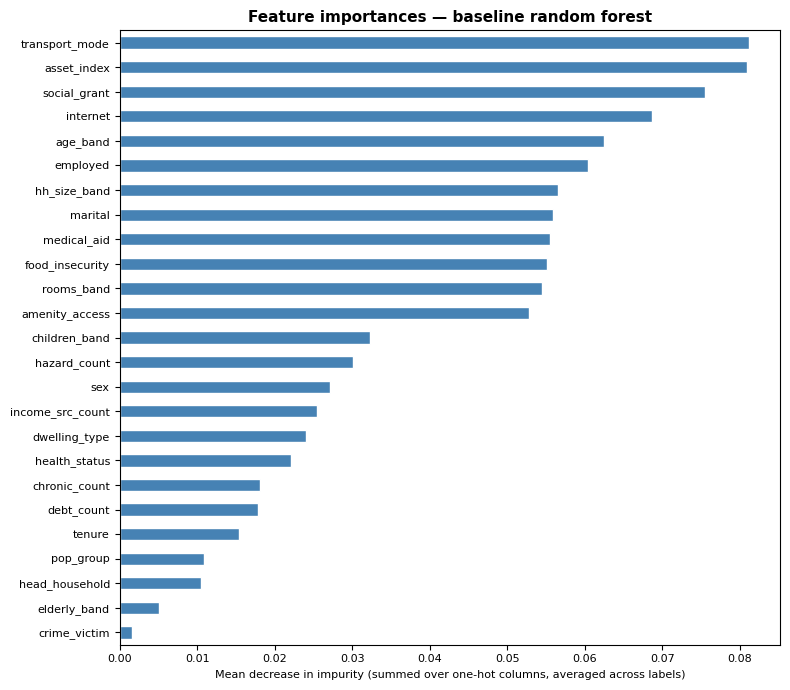

Chart saved.


In [19]:
# Feature importances — averaged across all five label-specific forests.
# Each forest is trained on one-hot columns, so we sum the importances of all
# one-hot columns belonging to each original feature.
ohe = model.named_steps['pre'].named_transformers_['cat']
group_sizes = [len(cats) for cats in ohe.categories_]   # one-hot cols per feature, in FEATURE_COLS order
mean_imp = np.mean(
    [est.feature_importances_ for est in model.named_steps['clf'].estimators_], axis=0
)

agg, start = {}, 0
for feat, size in zip(FEATURE_COLS, group_sizes):
    agg[feat] = mean_imp[start:start + size].sum()
    start += size
imp_df = pd.Series(agg).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
imp_df.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Mean decrease in impurity (summed over one-hot columns, averaged across labels)', fontsize=8)
ax.set_title('Feature importances — baseline random forest', fontsize=11, fontweight='bold')
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig(str(BASE / 'feature_importances.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved.')

## Predictions on the test set

Generate predictions for all rows in `test.csv`.

In [20]:
y_test_pred = model.predict(X_test)

pred_df = pd.DataFrame(y_test_pred, columns=TARGET_COLS)
pred_df.insert(0, ID_COL, test[ID_COL].values)

print(f'Predictions shape: {pred_df.shape}')
display(pred_df.head())


Predictions shape: (4060, 6)


,ID,no_water_access,no_sanitation_access,no_refuse_access,no_energy_access,no_education_access
0,93b33fc33c165ba91dee636c1acc1c2e,0,0,0,0,0
1,1879d989f42946a20183b6b709c26689,0,0,0,0,0
2,52c38eb71547edbf2134f3fc2773faa4,0,0,0,0,0
3,f75232c465978c0bef49a98938803464,0,0,0,0,0
4,afe194054599db1552d52b1abdedefba,0,0,0,0,0


## Create submission file

Merge predictions into the sample submission template, run a sanity check, then save to CSV. The submission file must contain exactly the columns in `sample_submission.csv`, in the same order.


In [21]:
# Merge into sample_submission column order
submission = sample_sub[[ID_COL]].merge(pred_df, on=ID_COL, how='left')
submission = submission[[ID_COL] + TARGET_COLS]
print('Submission preview:')
submission.head()

Submission preview:


,ID,no_water_access,no_sanitation_access,no_refuse_access,no_energy_access,no_education_access
0,93b33fc33c165ba91dee636c1acc1c2e,0,0,0,0,0
1,1879d989f42946a20183b6b709c26689,0,0,0,0,0
2,52c38eb71547edbf2134f3fc2773faa4,0,0,0,0,0
3,f75232c465978c0bef49a98938803464,0,0,0,0,0
4,afe194054599db1552d52b1abdedefba,0,0,0,0,0


In [22]:
# Sanity checks
assert list(submission.columns) == [ID_COL] + TARGET_COLS, 'Column order mismatch'
assert len(submission) == len(sample_sub), f'Row count mismatch: {len(submission)} vs {len(sample_sub)}'
assert submission.isna().sum().sum() == 0, 'Null values found in submission'
assert set(submission[ID_COL]) == set(sample_sub[ID_COL]), 'ID mismatch between submission and sample'
for col in TARGET_COLS:
    assert submission[col].isin([0, 1]).all(), f'{col} contains values other than 0 or 1'
print('All sanity checks passed.')
print(f'Submission shape  : {submission.shape}')
print('Predicted positives per label:')
print((submission[TARGET_COLS].mean() * 100).apply(lambda x: f'{x:.1f}%'))


All sanity checks passed.
Submission shape  : (4060, 6)
Predicted positives per label:
no_water_access         36.9%
no_sanitation_access    16.3%
no_refuse_access        28.6%
no_energy_access         4.2%
no_education_access     16.7%
dtype: object


In [23]:
submission.to_csv(SUBMISSION_FILE, index=False)
print(f'Submission saved to: {SUBMISSION_FILE}')


Submission saved to: submission.csv


## Ideas to improve

This baseline scores a validation **macro-F1 of roughly 0.39** (and a little higher once the decision thresholds are tuned, above). The score is not very great — but there is clear room to improve:

- **Take threshold tuning further.** The section above selects thresholds on the validation set; for a real leaderboard submission, select them with cross-validation (to avoid the optimistic bias) and apply `best_thresholds` to the test probabilities.
- **Encode the ordinal bands as ordered integers** (e.g. `asset_index`, `hh_size_band`, `health_status`) instead of one-hot, so the model can use their natural order.
- **Try gradient boosting** — `HistGradientBoostingClassifier`, XGBoost, or LightGBM — often stronger than a random forest on tabular data.
- **Exploit label co-occurrence** with a `ClassifierChain` instead of independent per-label forests, since the gaps are correlated.
- **Cross-validate** (combine train + val with `StratifiedKFold`) for a more reliable estimate and to tune hyper-parameters.